# G20 Sovereign Climate Risk Analysis

A data-driven analysis of carbon emissions trends, decoupling performance, and 2030 projections across G20 nations — framed through the lens of **sovereign climate risk**, a framework used by institutional investors to assess climate-related risks in government bonds and cross-border investments.

## Research Questions
1. Which countries are the largest emitters, and how have trends shifted since 1950?
2. Is there a statistically significant relationship between wealth (GDP per capita) and emissions intensity?
3. Which G20 countries have successfully decoupled economic growth from CO2 emissions?
4. What do machine learning models project for G20 emissions in 2030?

**Data Source:** [Our World in Data — CO2 and Greenhouse Gas Emissions](https://github.com/owid/co2-data)  
**Author:** Mingzhen Gao  
**Date:** May 2026

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

## 1. Data Loading & Cleaning

In [59]:
url = 'https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv'
df = pd.read_csv(url)

print(f'Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Year range: {df["year"].min()} to {df["year"].max()}')
print(f'Countries/regions: {df["country"].nunique()}')

Raw dataset: 50,411 rows, 79 columns
Year range: 1750 to 2024
Countries/regions: 254


In [60]:
# Keep only real countries (rows with iso_code) and data from 1950 onwards
# Rows without iso_code are continental/global aggregates (e.g. 'Africa', 'Asia')
df_filtered = df[(df['iso_code'].notna()) & (df['year'] >= 1950)].copy()

print(f'Filtered: {df_filtered.shape[0]:,} rows, {df_filtered["country"].nunique()} countries (1950–2024)')

Filtered: 16,350 rows, 218 countries (1950–2024)


## 2. Top 10 Emitters: Historical Trends (1950–2024)

In [61]:
# Identify Top 10 emitters by 2022 total CO2
df_2022 = df_filtered[df_filtered['year'] == 2022].copy()
df_2022['gdp_per_capita'] = df_2022['gdp'] / df_2022['population']

top10 = df_2022.sort_values('co2', ascending=False).head(10)
top10_countries = top10['country'].tolist()

print('Top 10 CO2 emitters in 2022:')
print(top10[['country', 'co2', 'co2_per_capita']].to_string(index=False))

Top 10 CO2 emitters in 2022:
      country       co2  co2_per_capita
        China 11711.808           8.218
United States  5055.403          14.802
        India  2831.132           1.986
       Russia  1675.461          11.509
        Japan  1029.645           8.237
         Iran   767.178           8.570
    Indonesia   758.021           2.719
      Germany   667.843           7.942
 Saudi Arabia   666.994          20.730
  South Korea   606.877          11.720


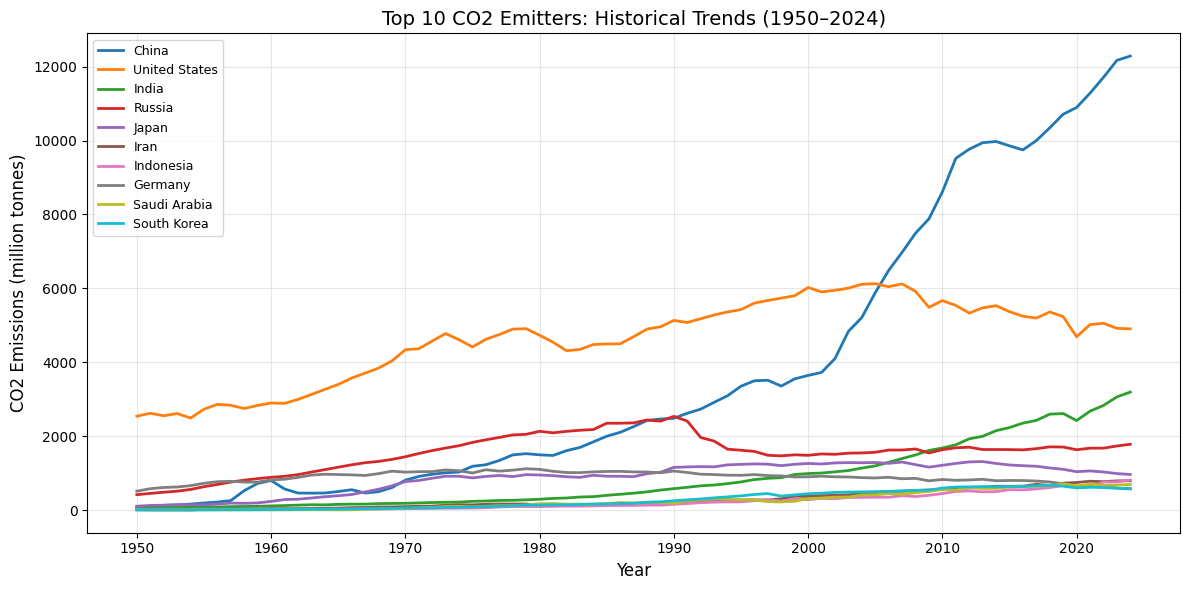

In [62]:
fig, ax = plt.subplots(figsize=(12, 6))

for country in top10_countries:
    data = df_filtered[df_filtered['country'] == country]
    ax.plot(data['year'], data['co2'], label=country, linewidth=2)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CO2 Emissions (million tonnes)', fontsize=12)
ax.set_title('Top 10 CO2 Emitters: Historical Trends (1950–2024)', fontsize=14)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_top10_trends.png', dpi=150)
plt.show()

**Key finding:** China's emissions surpassed the US around 2005 and accelerated sharply, driven by coal-intensive industrialization. The US has seen a gradual decline since ~2007, largely attributable to the shale gas revolution displacing coal in power generation.

## 3. CO2 per Capita vs. GDP per Capita (2022)

Bubble size = population. This separates the story of *total* emissions from *emissions intensity* per person — a distinction central to climate equity debates.

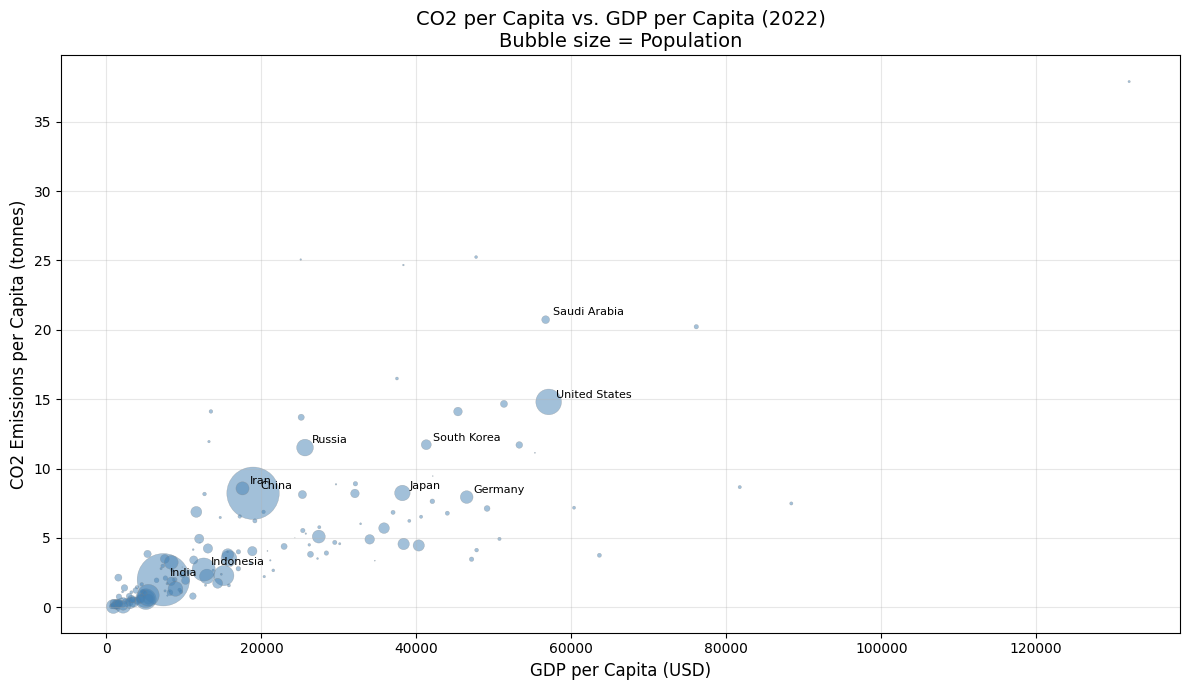

In [63]:
df_2022_clean = df_2022.dropna(subset=['gdp_per_capita', 'co2_per_capita', 'population'])

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(
    df_2022_clean['gdp_per_capita'],
    df_2022_clean['co2_per_capita'],
    s=df_2022_clean['population'] / 1_000_000,
    alpha=0.5, color='steelblue', edgecolors='gray', linewidths=0.3
)

for country in top10_countries:
    row = df_2022_clean[df_2022_clean['country'] == country]
    if not row.empty:
        ax.annotate(country,
                    xy=(row['gdp_per_capita'].values[0], row['co2_per_capita'].values[0]),
                    fontsize=8, xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('GDP per Capita (USD)', fontsize=12)
ax.set_ylabel('CO2 Emissions per Capita (tonnes)', fontsize=12)
ax.set_title('CO2 per Capita vs. GDP per Capita (2022)\nBubble size = Population', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_bubble.png', dpi=150)
plt.show()

**Key finding:** China emits 2.3× more than the US in total, yet its per-capita emissions (8.2t) are only 55% of the US level (14.8t). India, the 3rd largest emitter, has a per-capita footprint of just 2.0t — illustrating the fundamental tension between development rights and climate responsibility.

## 4. Statistical Analysis: GDP vs. Emissions Intensity

Testing whether the visual correlation between GDP per capita and CO2 per capita is statistically significant.

In [64]:
# Spearman correlation — robust to non-linear relationships and outliers
corr, pvalue = stats.spearmanr(
    df_2022_clean['gdp_per_capita'],
    df_2022_clean['co2_per_capita']
)
print(f'Spearman r  = {corr:.3f}')
print(f'P-value     = {pvalue:.2e}')
print(f'Sample size = {len(df_2022_clean)} countries')

Spearman r  = 0.892
P-value     = 1.06e-57
Sample size = 164 countries


In [65]:
# Log-linear regression: CO2_per_capita ~ log(GDP_per_capita)
# Log transformation appropriate because the relationship is multiplicative, not additive
df_2022_clean['log_gdp_per_capita'] = np.log(df_2022_clean['gdp_per_capita'])

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_2022_clean['log_gdp_per_capita'],
    df_2022_clean['co2_per_capita']
)
print(f'R²      = {r_value**2:.3f}')
print(f'Slope   = {slope:.3f}  (each 1-unit increase in log GDP → +{slope:.1f}t CO2 per capita)')
print(f'P-value = {p_value:.2e}')

R²      = 0.432
Slope   = 2.996  (each 1-unit increase in log GDP → +3.0t CO2 per capita)
P-value = 1.25e-21


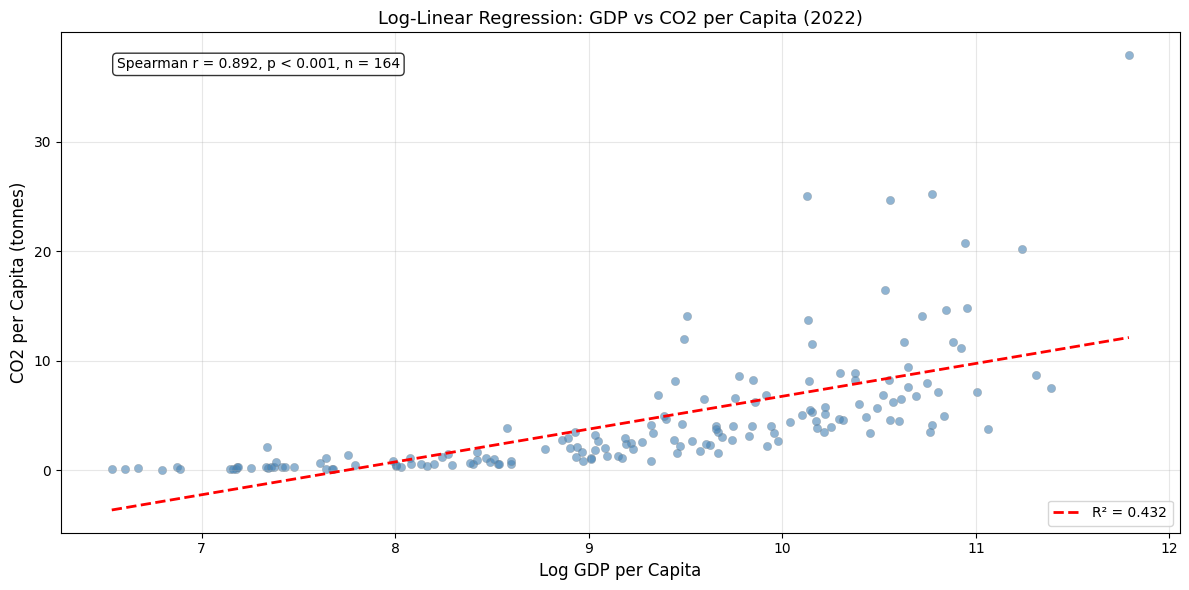

In [66]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_2022_clean['log_gdp_per_capita'], df_2022_clean['co2_per_capita'],
           alpha=0.6, color='steelblue', edgecolors='gray', linewidths=0.3)

x_line = df_2022_clean['log_gdp_per_capita'].sort_values()
ax.plot(x_line, slope * x_line + intercept,
        color='red', linewidth=2, linestyle='--', label=f'R² = {r_value**2:.3f}')

ax.text(0.05, 0.95, f'Spearman r = 0.892, p < 0.001, n = {len(df_2022_clean)}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Log GDP per Capita', fontsize=12)
ax.set_ylabel('CO2 per Capita (tonnes)', fontsize=12)
ax.set_title('Log-Linear Regression: GDP vs CO2 per Capita (2022)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_regression.png', dpi=150)
plt.show()

**Key finding:** Spearman r = 0.892 (p < 0.001) confirms a strong positive correlation between wealth and emissions intensity. The log-linear model (R² = 0.432) explains 43% of variance — meaning 57% is driven by other factors such as energy mix, industrial structure, and climate policy. These structural factors are precisely what ESG analysts target.

## 5. Emission Source Breakdown: China vs. United States

Structural differences in fuel mix explain why decarbonization paths diverge.

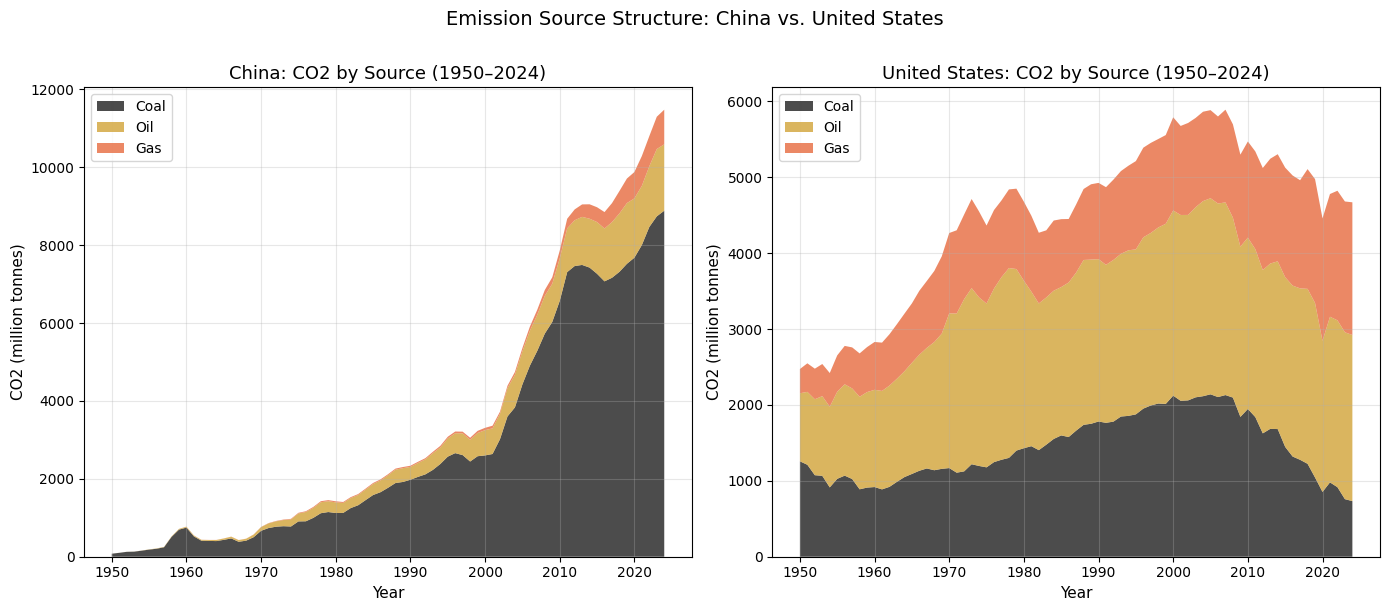

In [67]:
df_china = df_filtered[df_filtered['country'] == 'China']
df_us = df_filtered[df_filtered['country'] == 'United States']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2c2c2c', '#d4a843', '#e8734a']

for ax, data, title in zip(axes, [df_china, df_us], ['China', 'United States']):
    ax.stackplot(data['year'],
                 data['coal_co2'], data['oil_co2'], data['gas_co2'],
                 labels=['Coal', 'Oil', 'Gas'], colors=colors, alpha=0.85)
    ax.set_title(f'{title}: CO2 by Source (1950–2024)', fontsize=13)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('CO2 (million tonnes)', fontsize=11)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Emission Source Structure: China vs. United States', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig4_structure.png', dpi=150)
plt.show()

**Key finding:** China's emissions are ~70% coal-driven, creating structural lock-in that makes rapid decarbonization technically and economically harder. The US underwent a significant fuel transition after 2008: the shale gas boom displaced coal and drove a ~20% absolute reduction in emissions — without a major renewables expansion.

## 6. G20 Decoupling Analysis (1990–2024)

Using 1990 as baseline (= 100), we track GDP and CO2 relative growth. Countries below the diagonal have grown their economy faster than emissions — indicating decoupling.

In [68]:
g20 = ['China', 'United States', 'India', 'Japan', 'Germany',
       'United Kingdom', 'France', 'Italy', 'Canada', 'South Korea',
       'Russia', 'Australia', 'Brazil', 'Mexico', 'Indonesia',
       'Turkey', 'Saudi Arabia', 'Argentina', 'South Africa']

df_g20 = df_filtered[
    (df_filtered['country'].isin(g20)) &
    (df_filtered['year'] >= 1990)
].copy()

# Calculate index relative to 1990 baseline
result = []
for country in g20:
    data = df_g20[df_g20['country'] == country].copy()
    base_gdp = data[data['year'] == 1990]['gdp'].values[0]
    base_co2 = data[data['year'] == 1990]['co2'].values[0]
    data['gdp_index'] = data['gdp'] / base_gdp * 100
    data['co2_index'] = data['co2'] / base_co2 * 100
    result.append(data)

df_g20 = pd.concat(result)
print(f'G20 dataset: {df_g20["country"].nunique()} countries, {len(df_g20)} rows')

G20 dataset: 19 countries, 665 rows


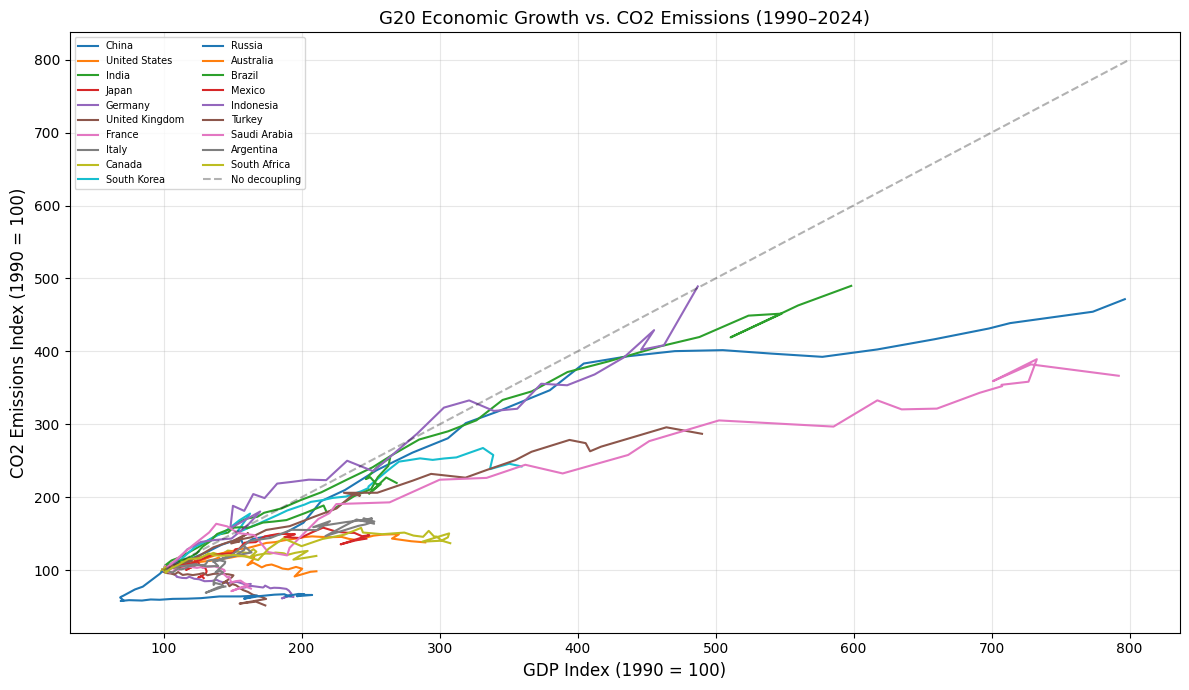

In [69]:
fig, ax = plt.subplots(figsize=(12, 7))

for country in g20:
    data = df_g20[df_g20['country'] == country].dropna(subset=['gdp_index', 'co2_index'])
    ax.plot(data['gdp_index'], data['co2_index'], label=country, linewidth=1.5)

ax.plot([100, 800], [100, 800], 'k--', alpha=0.3, linewidth=1.5, label='No decoupling')
ax.set_xlabel('GDP Index (1990 = 100)', fontsize=12)
ax.set_ylabel('CO2 Emissions Index (1990 = 100)', fontsize=12)
ax.set_title('G20 Economic Growth vs. CO2 Emissions (1990–2024)', fontsize=13)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_g20_decoupling.png', dpi=150)
plt.show()

In [70]:
# Decoupling score: CO2 index / GDP index
# Lower = better decoupling (emissions grew slower than economy)
# Score > 1 = emissions grew faster than GDP (negative decoupling)
df_score = df_g20[df_g20['year'] == 2022][['country', 'gdp_index', 'co2_index']].copy()
df_score['decoupling_score'] = df_score['co2_index'] / df_score['gdp_index']
df_score = df_score.sort_values('decoupling_score', ascending=False)

print(df_score[['country', 'gdp_index', 'co2_index', 'decoupling_score']].to_string(index=False))

       country  gdp_index  co2_index  decoupling_score
     Indonesia 487.105845 489.074204          1.004041
         India 598.303285 489.826242          0.818692
        Brazil 268.872185 219.547421          0.816549
         Japan 129.046625  89.158101          0.690898
   South Korea 359.395799 242.255629          0.674064
     Argentina 252.372392 163.803615          0.649055
         China 796.604070 471.578323          0.591986
        Turkey 490.178037 286.987941          0.585477
        Mexico 246.903013 143.269055          0.580265
        Canada 210.682097 119.571283          0.567544
         Italy 144.766561  77.614968          0.536139
     Australia 289.624106 138.127245          0.476919
 United States 210.728373  98.512051          0.467484
  Saudi Arabia 792.198336 366.538624          0.462685
        France 163.278098  74.778680          0.457984
  South Africa 307.729307 137.019947          0.445261
       Germany 193.972742  63.314897          0.326411
        Ru

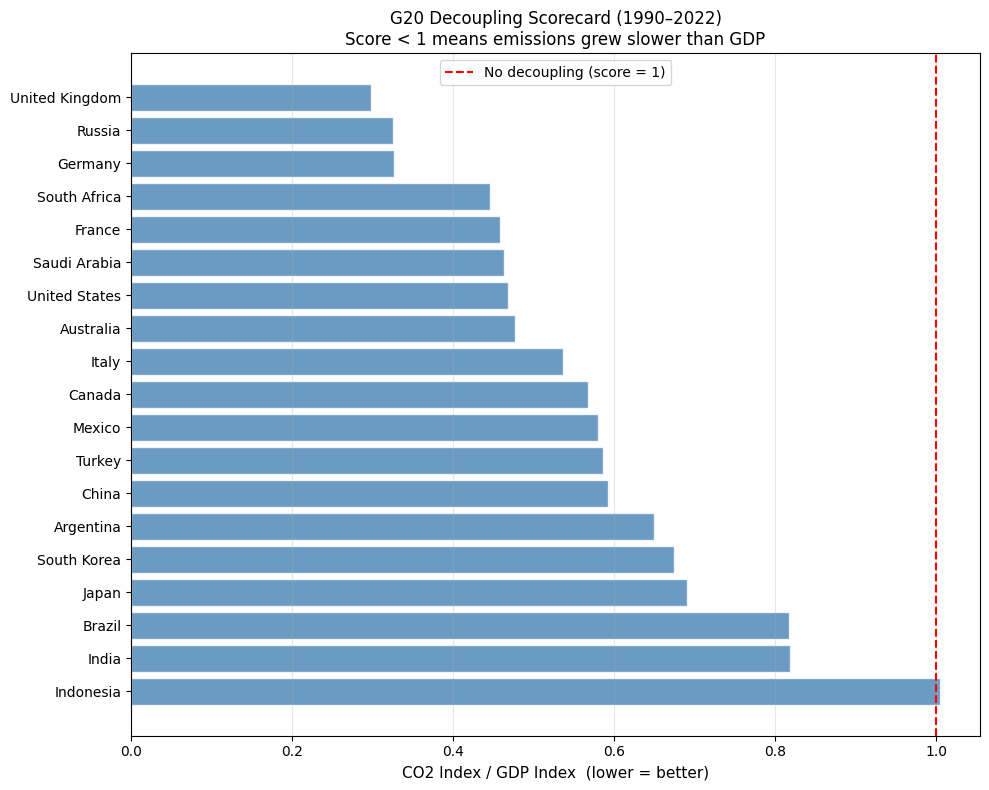

In [71]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_score['country'], df_score['decoupling_score'],
        color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='No decoupling (score = 1)')
ax.set_xlabel('CO2 Index / GDP Index  (lower = better)', fontsize=11)
ax.set_title('G20 Decoupling Scorecard (1990–2022)\nScore < 1 means emissions grew slower than GDP', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig6_decoupling_scorecard.png', dpi=150)
plt.show()

**Key finding:** All G20 economies achieved some decoupling (score < 1), but the gap is large. The UK (0.30), Germany (0.33), and Russia (0.32) lead — though Russia's score partly reflects post-Soviet economic contraction rather than green transition. Indonesia (1.00) is the only economy where emissions grew as fast as GDP.

> **Limitation:** Using 1990 as a universal baseline is imperfect — some countries had abnormally high or low emissions that year (e.g. Soviet-era Russia). A more robust analysis would use multiple baseline years.

## 7. Machine Learning: 2030 Emissions Projections

Using GDP and population as predictors (trained on 1990–2015, validated on 2016–2022), we project G20 emissions to 2030 under a business-as-usual scenario (3% annual GDP growth, 1% population growth).

In [72]:
features = ['year', 'gdp', 'population', 'co2']
df_ml = df_g20[features].dropna()

train = df_ml[df_ml['year'] <= 2015]
test  = df_ml[df_ml['year'] >  2015]

X_train = train[['year', 'gdp', 'population']]
y_train = train['co2']
X_test  = test[['year', 'gdp', 'population']]
y_test  = test['co2']

print(f'Train: {len(train)} rows (1990–2015) | Test: {len(test)} rows (2016–2022)')

Train: 494 rows (1990–2015) | Test: 133 rows (2016–2022)


In [73]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Model Comparison on Test Set (2016–2022):')
print(f'{"Model":<20} {"R²":>8} {"MAE (Mt)":>12}')
print('-' * 42)
print(f'{"Random Forest":<20} {r2_score(y_test, y_pred_rf):>8.3f} {mean_absolute_error(y_test, y_pred_rf):>12.1f}')
print(f'{"Linear Regression":<20} {r2_score(y_test, y_pred_lr):>8.3f} {mean_absolute_error(y_test, y_pred_lr):>12.1f}')

Model Comparison on Test Set (2016–2022):
Model                      R²     MAE (Mt)
------------------------------------------
Random Forest           0.616        497.2
Linear Regression       0.870        574.3


**Model selection:** Linear Regression achieves higher R² (0.870 vs 0.616) but severely overestimates emissions for large economies — China: ~20,000 Mt predicted vs ~11,700 Mt actual. This is because linear models extrapolate indefinitely and cannot capture diminishing returns at high GDP levels. Random Forest is more conservative and realistic for out-of-sample prediction.

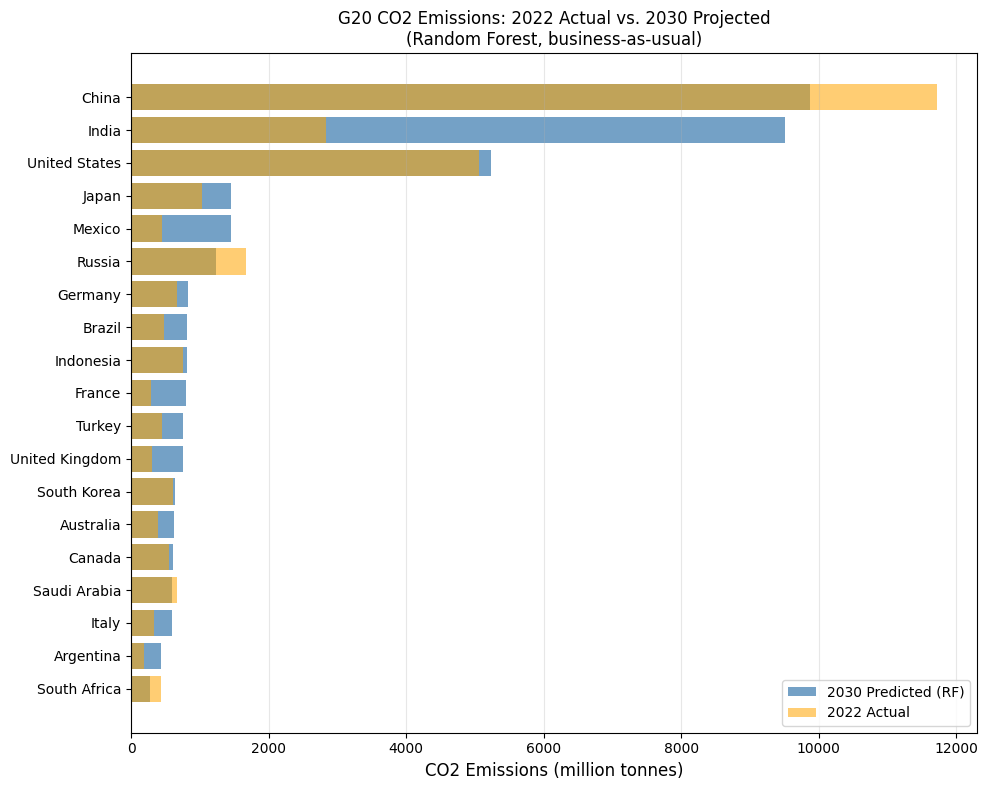

In [74]:
# 2030 projection using Random Forest (business-as-usual scenario)
df_2022_g20 = df_ml[df_ml['year'] == 2022].copy()
years_ahead = 2030 - 2022

df_2030 = df_2022_g20.copy()
df_2030['year'] = 2030
df_2030['gdp'] = df_2030['gdp'] * (1.03 ** years_ahead)        # 3% annual GDP growth
df_2030['population'] = df_2030['population'] * (1.01 ** years_ahead)  # 1% annual population growth

df_2030['co2_predicted_2030'] = rf.predict(df_2030[['year', 'gdp', 'population']])
df_2030['country'] = df_g20[df_g20['year'] == 2022]['country'].values

df_2030_plot = df_2030[['country', 'co2', 'co2_predicted_2030']].sort_values('co2_predicted_2030', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_2030_plot['country'], df_2030_plot['co2_predicted_2030'],
        label='2030 Predicted (RF)', alpha=0.75, color='steelblue')
ax.barh(df_2030_plot['country'], df_2030_plot['co2'],
        label='2022 Actual', alpha=0.55, color='orange')
ax.set_xlabel('CO2 Emissions (million tonnes)', fontsize=12)
ax.set_title('G20 CO2 Emissions: 2022 Actual vs. 2030 Projected\n(Random Forest, business-as-usual)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig7_2030_projection_rf.png', dpi=150)
plt.show()

**Key finding:** Under a business-as-usual scenario, India's emissions are projected to approach China's by 2030 — reflecting continued coal-driven industrialization. Most European economies show minimal change, consistent with their near-peak emissions profiles.

> **Important caveat:** These are extrapolations assuming current GDP and population growth rates. They do not account for policy changes, technology breakthroughs, or economic shocks.

## Summary

This analysis identifies three core tensions in sovereign climate risk:

| Finding | Implication |
|---------|-------------|
| China emits 2.3× the US in total, but 55% per capita | 'Who should cut first' is genuinely contested |
| China's ~70% coal dependency vs. US fuel transition | Structural lock-in makes decarbonization timelines asymmetric |
| India follows the no-decoupling path | The largest climate risk unknown for 2030+ |

**Next steps:** Add corporate-level analysis using CDP disclosure data to connect sovereign climate risk with firm-level ESG exposure.

---
*Data: Our World in Data CO2 Dataset | Tools: Python, pandas, matplotlib, scikit-learn, scipy*